# Packages

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from tabulate import tabulate
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score,roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder
from sklearn.compose import ColumnTransformer


c:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [2]:
data_cleaned = pd.read_csv(r'C:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\data\clean_data.csv', encoding='latin1')

C:\Users\natal\AppData\Local\Temp\ipykernel_11092\2270981868.py:1: DtypeWarning: Columns (14,19,36,42) have mixed types. Specify dtype option on import or set low_memory=False.
  data_cleaned = pd.read_csv(r'C:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\data\clean_data.csv', encoding='latin1')


In [3]:
data_cleaned.head()

,Unnamed: 0,tp_not,sem_not,id_agravo,dt_notific,nu_ano,sg_uf_not,id_municip,id_regiona,dt_diag,...,cli_icteri,cli_rinite,cli_anemia,cli_esplen,hepato,cli_osteo,lesoes,cli_outro,sin_outr_e,cli_pseudo
0,1,2,201334.0,A509,2013-08-22,2013,42,420395,1555.0,2007-12-01,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,ENCEFALOPATIA,2.0
1,2,2,1307.0,A509,2013-02-15,2013,33,330510,NaN,2008-10-31,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0
2,3,2,201326.0,A509,2013-06-24,2013,33,330350,NaN,2009-04-21,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0
3,4,2,201315.0,A509,2013-04-08,2013,24,240810,1416.0,2010-04-24,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0
4,5,2,201323.0,A509,2013-06-06,2013,33,330350,NaN,2010-07-31,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0


In [4]:
data_cleaned.shape

(251659, 65)

In [5]:
data_cleaned.columns = data_cleaned.columns.str.upper()

In [6]:
# Create outcome columns (death from congenital syphilis) based on EVOLUCAO
data_cleaned['OBITO_SIFILIS'] = data_cleaned['EVOLUCAO'].apply(lambda x: 1 if x == 2 else 0)


# Data cleaning

In [7]:
# Step 1: Remove all columns representing date
# Identify columns that begin with 'DT'
columns_with_dt = [col for col in data_cleaned.columns if col.startswith('DT')]

data_cleaned = data_cleaned.drop(columns=columns_with_dt)

print("Removed columns that begin with 'DT':", columns_with_dt)
print("Remaining columns in the dataset:", data_cleaned.columns)

Removed columns that begin with 'DT': ['DT_NOTIFIC', 'DT_DIAG', 'DT_OBITO']
Remaining columns in the dataset: Index(['UNNAMED: 0', 'TP_NOT', 'SEM_NOT', 'ID_AGRAVO', 'NU_ANO', 'SG_UF_NOT',
       'ID_MUNICIP', 'ID_REGIONA', 'SEM_DIAG', 'NU_IDADE_N', 'CS_SEXO',
       'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI',
       'ID_RG_RESI', 'ID_PAIS', 'ANT_IDADE', 'ANT_RACA', 'ID_OCUPA_N',
       'ESCOLMAE', 'ANT_PRE_NA', 'UF_PRE_NAT', 'MUN_PRE_NA', 'ANTSIFIL_N',
       'LAB_PARTO', 'LAB_TITU_2', 'LAB_DT3', 'LAB_CONF', 'TRA_ESQUEM',
       'TRA_DT', 'ANT_TRATAD', 'ANT_UF_CRI', 'ANT_MUNI_C', 'LABC_SANGU',
       'LABC_TIT_1', 'LABC_DT_1', 'LABC_IGG', 'LABC_DT', 'LABC_LIQUO',
       'LABC_TIT_2', 'LABC_DT_2', 'LABC_TITUL', 'LABC_EVIDE', 'LABC_LIQ_1',
       'TRA_DIAG_T', 'TRA_ESQU_1', 'DS_ESQUEMA', 'EVOLUCAO', 'EVO_DIAG_N',
       'TRA_DIAG_C', 'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN',
       'HEPATO', 'CLI_OSTEO', 'LESOES', 'CLI_OUTRO', 'SIN_OUTR_E',
       'CLI_PSE

In [8]:
# Step 2: Remove columns representing laboratory data because they will certainly be related to the outcome
# Identify columns that begin with 'LAB'
columns_with_lab = [col for col in data_cleaned.columns if col.startswith('LAB')]

data_cleaned = data_cleaned.drop(columns=columns_with_lab)

print("Removed columns that begin with 'LAB':", columns_with_lab)
print("Remaining columns in the dataset:", data_cleaned.columns)

Removed columns that begin with 'LAB': ['LAB_PARTO', 'LAB_TITU_2', 'LAB_DT3', 'LAB_CONF', 'LABC_SANGU', 'LABC_TIT_1', 'LABC_DT_1', 'LABC_IGG', 'LABC_DT', 'LABC_LIQUO', 'LABC_TIT_2', 'LABC_DT_2', 'LABC_TITUL', 'LABC_EVIDE', 'LABC_LIQ_1']
Remaining columns in the dataset: Index(['UNNAMED: 0', 'TP_NOT', 'SEM_NOT', 'ID_AGRAVO', 'NU_ANO', 'SG_UF_NOT',
       'ID_MUNICIP', 'ID_REGIONA', 'SEM_DIAG', 'NU_IDADE_N', 'CS_SEXO',
       'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI',
       'ID_RG_RESI', 'ID_PAIS', 'ANT_IDADE', 'ANT_RACA', 'ID_OCUPA_N',
       'ESCOLMAE', 'ANT_PRE_NA', 'UF_PRE_NAT', 'MUN_PRE_NA', 'ANTSIFIL_N',
       'TRA_ESQUEM', 'TRA_DT', 'ANT_TRATAD', 'ANT_UF_CRI', 'ANT_MUNI_C',
       'TRA_DIAG_T', 'TRA_ESQU_1', 'DS_ESQUEMA', 'EVOLUCAO', 'EVO_DIAG_N',
       'TRA_DIAG_C', 'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN',
       'HEPATO', 'CLI_OSTEO', 'LESOES', 'CLI_OUTRO', 'SIN_OUTR_E',
       'CLI_PSEUDO', 'OBITO_SIFILIS'],
      dtype='object')


In [9]:
# Step 3: Remove columns that start with 'ID'
# Columns that start with "ID"

id_columns = [col for col in data_cleaned.columns if col.startswith('ID')]
print("Columns that start with 'ID':", id_columns)

data_cleaned = data_cleaned.drop(columns=id_columns)

print("Columns remaining in the dataset after removing columns that start with 'ID':")
print(data_cleaned.columns)

Columns that start with 'ID': ['ID_AGRAVO', 'ID_MUNICIP', 'ID_REGIONA', 'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'ID_OCUPA_N']
Columns remaining in the dataset after removing columns that start with 'ID':
Index(['UNNAMED: 0', 'TP_NOT', 'SEM_NOT', 'NU_ANO', 'SG_UF_NOT', 'SEM_DIAG',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF',
       'ANT_IDADE', 'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA', 'UF_PRE_NAT',
       'MUN_PRE_NA', 'ANTSIFIL_N', 'TRA_ESQUEM', 'TRA_DT', 'ANT_TRATAD',
       'ANT_UF_CRI', 'ANT_MUNI_C', 'TRA_DIAG_T', 'TRA_ESQU_1', 'DS_ESQUEMA',
       'EVOLUCAO', 'EVO_DIAG_N', 'TRA_DIAG_C', 'CLI_ICTERI', 'CLI_RINITE',
       'CLI_ANEMIA', 'CLI_ESPLEN', 'HEPATO', 'CLI_OSTEO', 'LESOES',
       'CLI_OUTRO', 'SIN_OUTR_E', 'CLI_PSEUDO', 'OBITO_SIFILIS'],
      dtype='object')


In [10]:
# Step 4: Remove columns that don't make sense to consider
# List of columns to remove

columns_to_remove = [
'TP_NOT', 'SEM_NOT', 'NU_ANO', 'SG_UF_NOT', 'CS_SEXO', 'SG_UF',
'ANT_UF_CRI', 'ANT_MUNI_C', 'EVOLUCAO', 'EVO_DIAG_N', 'CLI_OUTRO', 'ANO',
'TRA_DT', 'SEM_DIAG', 'DS_ESQUEMA', 'SIN_OUTR_E', 'UNNAMED: 0', 'TRA_DIAG_C'
]

data_cleaned = data_cleaned.drop(columns=columns_to_remove, errors='ignore')

print("Columns remaining in the dataset after removal:")
print(data_cleaned.columns)

Columns remaining in the dataset after removal:
Index(['NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'ANT_IDADE',
       'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA', 'UF_PRE_NAT', 'MUN_PRE_NA',
       'ANTSIFIL_N', 'TRA_ESQUEM', 'ANT_TRATAD', 'TRA_DIAG_T', 'TRA_ESQU_1',
       'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN', 'HEPATO',
       'CLI_OSTEO', 'LESOES', 'CLI_PSEUDO', 'OBITO_SIFILIS'],
      dtype='object')


In [11]:
# Step 5: Remove the geographic location variables from prenatal care
# These variables represent the municipality and state where prenatal care was provided,
# and introduce additional complexity that does not directly contribute to the analysis of the
# clinical factors associated with congenital syphilis. Conclusions about the impact of geographic location
# are difficult to draw without a more in-depth analysis, so we chose
# to remove them to focus on variables directly related to the clinical outcome.

# List of columns to be removed in Step 5
columns_to_remove_step_5 = ['MUN_PRE_NA', 'UF_PRE_NAT']

data_cleaned = data_cleaned.drop(columns=columns_to_remove_step_5, errors='ignore')

print("Columns remaining in the dataset after removing Step 5:")
print(data_cleaned.columns)

Columns remaining in the dataset after removing Step 5:
Index(['NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'ANT_IDADE',
       'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA', 'ANTSIFIL_N', 'TRA_ESQUEM',
       'ANT_TRATAD', 'TRA_DIAG_T', 'TRA_ESQU_1', 'CLI_ICTERI', 'CLI_RINITE',
       'CLI_ANEMIA', 'CLI_ESPLEN', 'HEPATO', 'CLI_OSTEO', 'LESOES',
       'CLI_PSEUDO', 'OBITO_SIFILIS'],
      dtype='object')


# Data manipulation

In [12]:
# Separate categorical and numeric variables
categorical_features = ['CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA',
                        'ANTSIFIL_N', 'TRA_ESQUEM', 'ANT_TRATAD', 'TRA_DIAG_T', 'TRA_ESQU_1',
                        'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN','HEPATO',
                        'CLI_OSTEO', 'LESOES', 'CLI_PSEUDO']

numerical_features = [col for col in data_cleaned.columns if col not in categorical_features + ['OBITO_SIFILIS', 'ABORTION', 'STILLBORN']]

# Create copies of the variable lists to avoid modifications to the original (and to be used in another implementation)
categorical_features_rm = categorical_features.copy()
numerical_features_rm = numerical_features.copy()

# Create copies of the variable lists to preserve them
original_categorical_features = categorical_features.copy()
original_numerical_features = numerical_features.copy()

# Check the copies for verification
print("Copy of original categorical variables:", original_categorical_features)
print("Copy of original numerical variables:", original_numerical_features)

Copy of original categorical variables: ['CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA', 'ANTSIFIL_N', 'TRA_ESQUEM', 'ANT_TRATAD', 'TRA_DIAG_T', 'TRA_ESQU_1', 'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN', 'HEPATO', 'CLI_OSTEO', 'LESOES', 'CLI_PSEUDO']
Copy of original numerical variables: ['NU_IDADE_N', 'ANT_IDADE']


In [13]:
X = data_cleaned.drop(columns=['OBITO_SIFILIS'])
y = data_cleaned['OBITO_SIFILIS'] 

# Balancing

In [14]:
# Apply down centering
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

In [15]:
# Convert categorical variables to strings after undersampling
# Since the numbers in these categorical variables are just labels and have no ordinal meaning, converting to strings is the correct approach.
for col in categorical_features:
    X_resampled[col] = X_resampled[col].astype(str)

# Train e Test (General 70/30)

In [16]:
# Split balanced data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Variables

In [17]:
for idx, col in enumerate(X_train.columns):
    print(f"{idx}: {col}")

0: NU_IDADE_N
1: CS_GESTANT
2: CS_RACA
3: CS_ESCOL_N
4: ANT_IDADE
5: ANT_RACA
6: ESCOLMAE
7: ANT_PRE_NA
8: ANTSIFIL_N
9: TRA_ESQUEM
10: ANT_TRATAD
11: TRA_DIAG_T
12: TRA_ESQU_1
13: CLI_ICTERI
14: CLI_RINITE
15: CLI_ANEMIA
16: CLI_ESPLEN
17: HEPATO
18: CLI_OSTEO
19: LESOES
20: CLI_PSEUDO


In [18]:
X_train = X_train.drop(columns=['NU_IDADE_N','CS_RACA','CS_ESCOL_N'])
X_test = X_test.drop(columns=['NU_IDADE_N','CS_RACA','CS_ESCOL_N'])

**Description of variables**

CS_GESTANT:
Patient's gestational age.

ANT_IDADE: 
Maternal age at the time of case notification.

ANT_RACA: 
Maternal race 

ESCOLMAE: 
Maternal education level at the time of notification.

ANT_PRE_NA: 
Indicates whether the mother underwent prenatal care during pregnancy.

ANTSIFIL_N: 
Timing of syphilis diagnosis

TRA_ESQUEM: 
Adequacy of maternal treatment for syphilis

ANT_TRATAD: 
Information on whether the sexual partner(s) received treatment for syphilis.

TRA_DIAG_T: 
Radiological diagnosis of bone abnormalities (osteochondritis, periostitis, rarefaction, "saber-shaped" tibia).

TRA_ESQU_1: 
Treatment regimen used for congenital syphilis (in children).

CLI_ICTERI: 
Presence of jaundice at the newborn’s physical examination.

CLI_RINITE: 
Presence of mucopurulent rhinitis in the newborn.

CLI_ANEMIA: 
Presence of anemia in the newborn.

CLI_ESPLEN: 
Presence of splenomegaly in the newborn.

HEPATO: 
Presence of hepatomegaly in the newborn.

CLI_OSTEO: 
Presence of osteoarticular lesions or bone pain upon manipulation.

LESOES: 
Presence of skin lesions (bullous, desquamative, papular, or generalized rashes).

CLI_PSEUDO: 
Presence of pseudoparalysis, usually observed when handling the newborn .

18 variables

In [19]:
X_train.shape


(4904, 18)

In [20]:
X_test.shape


(2102, 18)

In [21]:
y_train.shape


(4904,)

In [22]:
y_test.shape

(2102,)

In [24]:
# Pre processing

for col in X_train.select_dtypes(include=['object', 'category']).columns:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)


numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])




🔹 Training and evaluating SVM...

Cross-validation results (folds):
Accuracy por fold: [0.78004073 0.79429735 0.74949084 0.79837067 0.79591837 0.79795918
 0.78367347 0.74693878 0.78367347 0.77346939]
Média Accuracy: 0.7804
Precision por fold: [0.80519481 0.81355932 0.79716981 0.8440367  0.81702128 0.80912863
 0.79583333 0.75833333 0.81415929 0.81278539]
Média Precision: 0.8067
Recall por fold: [0.74698795 0.77108434 0.67871486 0.73895582 0.77108434 0.78629032
 0.77016129 0.73387097 0.74193548 0.71774194]
Média Recall: 0.7457
F1 por fold: [0.775      0.79175258 0.73318872 0.78800857 0.79338843 0.79754601
 0.78278689 0.74590164 0.77637131 0.76231263]
Média F1: 0.7746
Roc_auc por fold: [0.8507667  0.8486591  0.80294733 0.85723058 0.85816294 0.85071481
 0.85886264 0.81463276 0.84177553 0.83132831]
Média Roc_auc: 0.8415


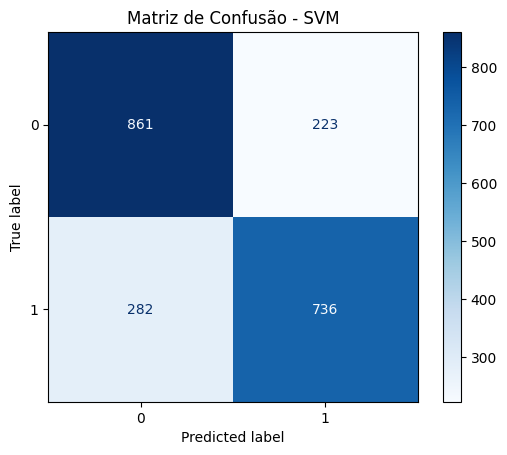


🔹 Training and evaluating Regressão Logística...

Cross-validation results (folds):
Accuracy por fold: [0.75560081 0.79226069 0.75763747 0.79633401 0.80612245 0.7877551
 0.78979592 0.76122449 0.77142857 0.78163265]
Média Accuracy: 0.7800
Precision por fold: [0.77446809 0.80753138 0.78761062 0.83111111 0.82352941 0.79752066
 0.80082988 0.77405858 0.79310345 0.8161435 ]
Média Precision: 0.8006
Recall por fold: [0.73092369 0.7751004  0.71485944 0.75100402 0.78714859 0.77822581
 0.77822581 0.74596774 0.74193548 0.73387097]
Média Recall: 0.7537
F1 por fold: [0.75206612 0.79098361 0.74947368 0.78902954 0.80492813 0.7877551
 0.78936605 0.75975359 0.76666667 0.77282378]
Média F1: 0.7763
Roc_auc por fold: [0.84250224 0.86183577 0.81391682 0.84568024 0.86051259 0.85341409
 0.85203113 0.83202813 0.84197547 0.83857638]
Média Roc_auc: 0.8442


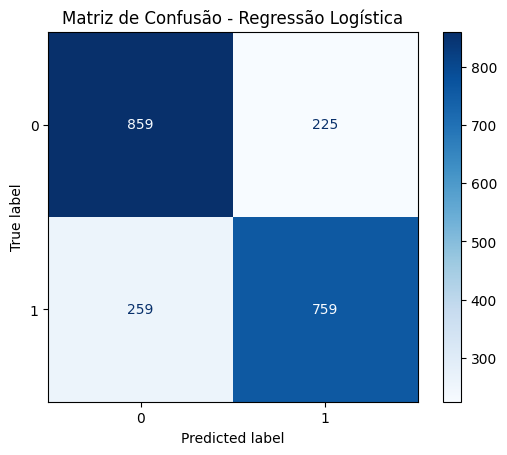


🔹 Training and evaluating Random Forest...

Cross-validation results (folds):
Accuracy por fold: [0.78004073 0.79429735 0.75560081 0.79633401 0.80408163 0.7877551
 0.78979592 0.75102041 0.79387755 0.78163265]
Média Accuracy: 0.7834
Precision por fold: [0.81057269 0.80327869 0.8028169  0.84651163 0.82832618 0.8
 0.80851064 0.75819672 0.8209607  0.82191781]
Média Precision: 0.8101
Recall por fold: [0.73895582 0.78714859 0.68674699 0.73092369 0.7751004  0.77419355
 0.76612903 0.74596774 0.75806452 0.72580645]
Média Recall: 0.7489
F1 por fold: [0.77310924 0.79513185 0.74025974 0.78448276 0.80082988 0.78688525
 0.78674948 0.75203252 0.78825996 0.77087794]
Média F1: 0.7779
Roc_auc por fold: [0.86135451 0.86430847 0.81089648 0.84251054 0.86197904 0.86227839
 0.86127866 0.83494401 0.86157025 0.84979006]
Média Roc_auc: 0.8511


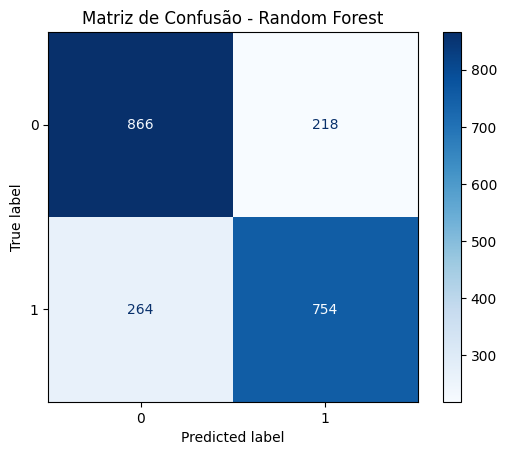


🔹 Training and evaluating XGBoost...


c:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:12:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:12:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:12:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\.venv\Lib\site


Cross-validation results (folds):
Accuracy por fold: [0.75967413 0.78411405 0.74541752 0.78615071 0.78367347 0.77142857
 0.78571429 0.75918367 0.77755102 0.77142857]
Média Accuracy: 0.7724
Precision por fold: [0.77637131 0.80168776 0.76956522 0.81304348 0.78947368 0.78333333
 0.79916318 0.76209677 0.80349345 0.80088496]
Média Precision: 0.7899
Recall por fold: [0.73895582 0.76305221 0.71084337 0.75100402 0.78313253 0.75806452
 0.77016129 0.76209677 0.74193548 0.72983871]
Média Recall: 0.7509
F1 por fold: [0.75720165 0.781893   0.73903967 0.78079332 0.78629032 0.7704918
 0.78439425 0.76209677 0.77148847 0.76371308]
Média F1: 0.7697
Roc_auc por fold: [0.85403598 0.85805204 0.81597464 0.84031166 0.85612991 0.86559417
 0.85804619 0.83807651 0.84415822 0.84376666]
Média Roc_auc: 0.8474


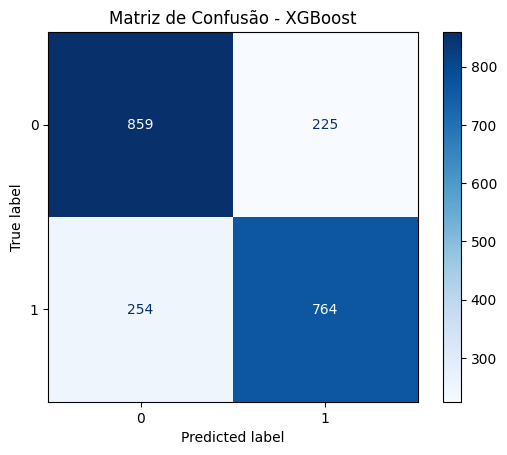


🔹 Training and evaluating CatBoost...

Cross-validation results (folds):
Accuracy por fold: [0.76985743 0.79022403 0.7311609  0.78818737 0.78367347 0.78367347
 0.79183673 0.76734694 0.76734694 0.76530612]
Média Accuracy: 0.7739
Precision por fold: [0.78099174 0.80932203 0.75770925 0.8280543  0.79916318 0.79098361
 0.79674797 0.77016129 0.77916667 0.80365297]
Média Precision: 0.7916
Recall por fold: [0.75903614 0.76706827 0.69076305 0.73493976 0.76706827 0.77822581
 0.79032258 0.77016129 0.75403226 0.70967742]
Média Recall: 0.7521
F1 por fold: [0.76985743 0.78762887 0.72268908 0.7787234  0.78278689 0.78455285
 0.79352227 0.77016129 0.76639344 0.75374732]
Média F1: 0.7710
Roc_auc por fold: [0.8564423  0.86495569 0.8002257  0.83515882 0.84819777 0.86159524
 0.85459711 0.83694348 0.84055918 0.84082578]
Média Roc_auc: 0.8440


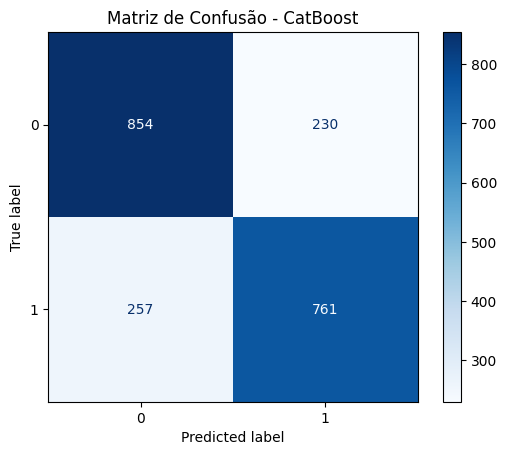



📊 Comparative Results (sorted by Test AUC):


,Model,CV Accuracy Mean,CV F1 Mean,CV AUC Mean,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC,Best Parameters
0,Random Forest,0.783444,0.777862,0.851091,0.770695,0.775720,0.740668,0.757789,0.849326,"{'clf__max_depth': 10, 'clf__n_estimators': 100}"
1,XGBoost,0.772434,0.769740,0.847415,0.772122,0.772497,0.750491,0.761335,0.844766,"{'clf__max_depth': 3, 'clf__n_estimators': 100}"
2,CatBoost,0.773861,0.771006,0.843950,0.768316,0.767911,0.747544,0.757591,0.842249,"{'clf__depth': 4, 'clf__learning_rate': 0.05}"
3,Regressão Logística,0.779979,0.776285,0.844247,0.769743,0.771341,0.745580,0.758242,0.838432,{'clf__C': 10}
4,SVM,0.780383,0.774626,0.841508,0.759753,0.767466,0.722986,0.744562,0.834237,"{'clf__C': 1, 'clf__kernel': 'rbf'}"


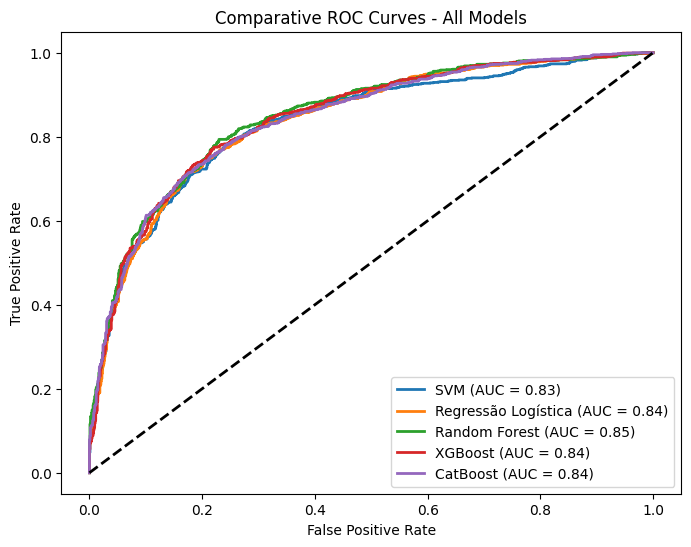

In [25]:
models = {
    "SVM": (
        SVC(probability=True, random_state=42),
        {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf']}
    ),
    "Regressão Logística": (
        LogisticRegression(max_iter=1000, random_state=42),
        {'clf__C': [0.1, 1, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {'clf__n_estimators': [100, 200],
         'clf__max_depth': [None, 10, 20]}
    ),
    "XGBoost": (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        {'clf__n_estimators': [100, 200],
         'clf__max_depth': [3, 5]}
    ),
    "CatBoost": (
        CatBoostClassifier(verbose=0, random_state=42),
        {'clf__depth': [4, 6],
         'clf__learning_rate': [0.05, 0.1]}
    )
}

# =====================================================
# 🔹 Training and Validation
# =====================================================

results = []
roc_curves = {}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, (model, grid_params) in models.items():
    print(f"\n🔹 Training and evaluating {name}...")

    # Pipeline com SelectKBest
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('select', SelectKBest(score_func=f_classif, k='all')),
        ('clf', model)
    ])

    # GridSearchCV
    grid = GridSearchCV(pipeline, grid_params, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train.values.ravel())

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    # =====================================================
    # 🔹 Cross-validation com várias métricas
    # =====================================================
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    from sklearn.model_selection import cross_validate

    cv_scores = cross_validate(best_model, X_train, y_train.values.ravel(),
                               cv=cv, scoring=scoring, return_train_score=False)

    print("\nCross-validation results (folds):")
    for metric in scoring:
        print(f"{metric.capitalize()} por fold: {cv_scores[f'test_{metric}']}")
        print(f"Média {metric.capitalize()}: {np.mean(cv_scores[f'test_{metric}']):.4f}")

    # =====================================================
    # 🔹 Test Set Evaluation
    # =====================================================
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    acc_test = accuracy_score(y_test, y_pred)
    prec_test = precision_score(y_test, y_pred)
    rec_test = recall_score(y_test, y_pred)
    f1_test = f1_score(y_test, y_pred)
    auc_test = roc_auc_score(y_test, y_prob)

    # =====================================================
    # 🔹 Confusion Matrix
    # =====================================================
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusão - {name}")
    plt.show()

    # =====================================================
    # 🔹 ROC Curve
    # =====================================================
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_curves[name] = (fpr, tpr, roc_auc)

    # =====================================================
    # 🔹 Save results
    # =====================================================
    results.append({
        'Model': name,
        'CV Accuracy Mean': np.mean(cv_scores['test_accuracy']),
        'CV F1 Mean': np.mean(cv_scores['test_f1']),
        'CV AUC Mean': np.mean(cv_scores['test_roc_auc']),
        'Test Accuracy': acc_test,
        'Test Precision': prec_test,
        'Test Recall': rec_test,
        'Test F1': f1_test,
        'Test AUC': auc_test,
        'Best Parameters': best_params
    })

# =====================================================
# 🔹 Model Comparison
# =====================================================

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Test AUC', ascending=False).reset_index(drop=True)

print("\n\n📊 Comparative Results (sorted by Test AUC):")
display(df_results)

# =====================================================
# 🔹 ROC Curves Comparison
# =====================================================
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in roc_curves.items():
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparative ROC Curves - All Models')
plt.legend(loc='lower right')
plt.show()

# Features Importances

In [27]:
# Identify and retrain the best Random Forest model using its best parameters
rf_model, rf_params = models["Random Forest"]

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('select', SelectKBest(score_func=f_classif, k='all')),
    ('clf', rf_model)
])

grid_rf = GridSearchCV(rf_pipeline, rf_params, cv=cv, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train.values.ravel())

best_rf_model = grid_rf.best_estimator_
rf_clf = best_rf_model.named_steps['clf']

print("\n✅ Best Random Forest Parameters:", grid_rf.best_params_)

# =====================================================
# 🔹 Feature Names after preprocessing
# =====================================================

feature_names = best_rf_model.named_steps['preprocess'].get_feature_names_out()
feature_names = best_rf_model.named_steps['select'].get_feature_names_out(feature_names)

X_train_transformed = best_rf_model.named_steps['preprocess'].transform(X_train)
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
X_train_transformed = X_train_transformed.astype(np.float64)

# =====================================================
# 🔹 Built-in Feature Importance
# =====================================================

importances = rf_clf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

print("\n📊 Top 10 Random Forest Feature Importances:")
display(feat_imp_df)

# =====================================================
# 🔹 SHAP Values (TreeExplainer)
# =====================================================

explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_train_transformed)

# Handle binary classification SHAP output
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_to_plot = shap_values




✅ Best Random Forest Parameters: {'clf__max_depth': 10, 'clf__n_estimators': 100}

📊 Top 10 Random Forest Feature Importances:


,Feature,Importance
48,cat__TRA_ESQU_1_5,0.117848
71,cat__HEPATO_2.0,0.077901
61,cat__CLI_ANEMIA_2.0,0.055952
42,cat__TRA_DIAG_T_3.0,0.051180
41,cat__TRA_DIAG_T_2.0,0.047530
81,cat__LESOES_2.0,0.046543
0,num__ANT_IDADE,0.036713
66,cat__CLI_ESPLEN_2.0,0.035898
70,cat__HEPATO_1.0,0.032653
44,cat__TRA_ESQU_1_1,0.027424


5. Not performed (TRA_ESQU_1)
2. No (HEPATO)
2. No (ANEMIA)
3. No applicable (TRA_DIAG_T)
2. No (TRA_DIAG_T)
2. No (LESOES)
2. No (CLI_ESPLEN)
1. Yes (HEPATO)
1. Crystalline penicillin G 100,000–150,000 IU/kg/day (10 days) (TRA_ESQU_1)

############################################################################

Codes:

1. Crystalline penicillin G 100,000–150,000 IU/kg/day (10 days) 
2. Procaine penicillin G 50,000 IU/kg/day (10 days) 
3. Benzathine penicillin G 50,000 IU/kg/day (single dose) 
4. Other regimen 
5. Not performed 
6. Not applicable 
9. Ignored

TRA_ESQU_1
Treatment regimen used for congenital syphilis (in children).

1. Yes 
2. No 
3. Not applicable 
9. Ignored

HEPATO:
Presence of hepatomegaly in the newborn.
ANEMIA:
Presence of anemia in the newborn.
TRA_DIAG_T:
Radiological diagnosis of bone abnormalities (osteochondritis, periostitis, rarefaction, "saber-shaped" tibia).
LESOES:
Presence of skin lesions (bullous, desquamative, papular, or generalized rashes).
CLI_ESPLEN:
Presence of splenomegaly in the newborn.


ANT_IDADE:
Maternal age at the time of case notification.

# Feature Importances - graph

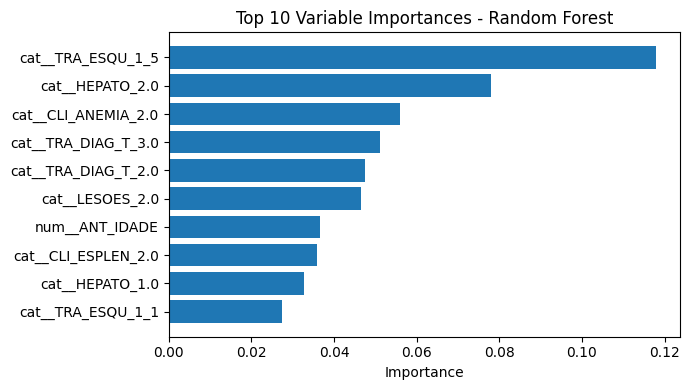

In [28]:
preproc = best_rf_model.named_steps['preprocess']
select = best_rf_model.named_steps['select']
names_after_preproc = preproc.get_feature_names_out()           
selected_feature_names = select.get_feature_names_out(names_after_preproc)

X_preproc = preproc.transform(X_train)
if hasattr(X_preproc, "toarray"):
    X_preproc = X_preproc.toarray()
X_preproc = X_preproc.astype(np.float64)
X_selected = select.transform(X_preproc)


# graph

plt.figure(figsize=(7, 4))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Variable Importances - Random Forest")
plt.tight_layout()
plt.show()



# Shap graph

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 200/200 [15:20<00:00,  4.60s/it]


Shape shap_values: (200, 90)
Shape X_selected: (200, 90)


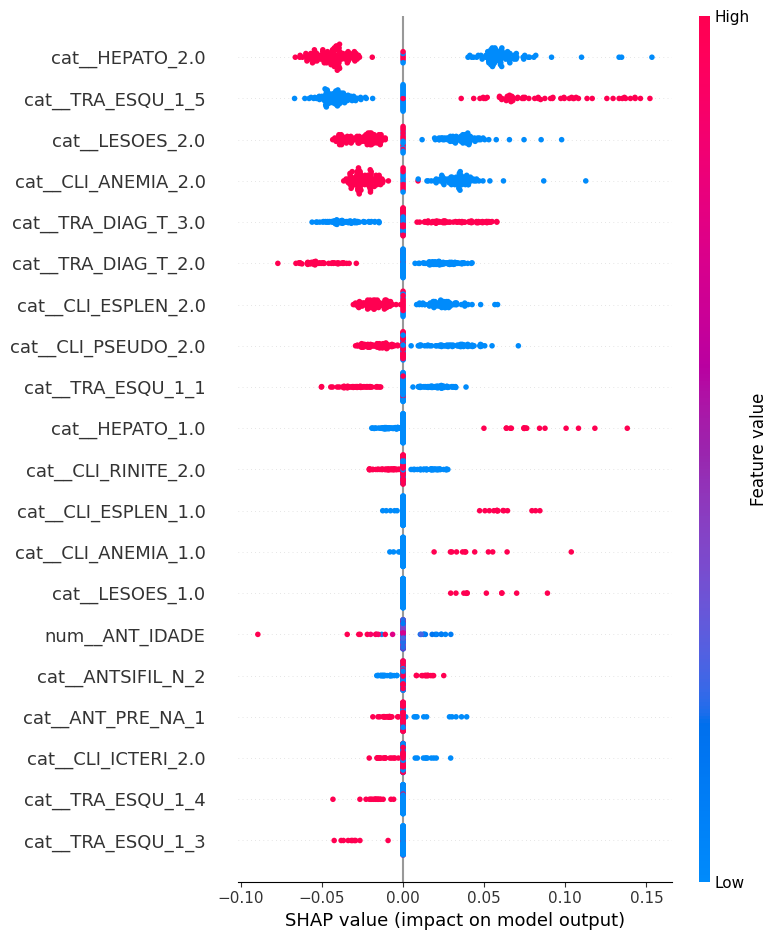

In [29]:

X_sample = shap.sample(X_selected, 200, random_state=42)

explainer = shap.KernelExplainer(lambda x: rf_clf.predict_proba(x)[:, 1], X_sample)

shap_values = explainer.shap_values(X_selected[:200])

print("Shape shap_values:", shap_values.shape)
print("Shape X_selected:", X_selected[:200].shape)

shap.summary_plot(
    shap_values,
    X_selected[:200],
    feature_names=selected_feature_names,
    show=True
)